In [177]:
import pandas as pd
import numpy as np
import time
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier


In [178]:
train_path = "../data/data_preprocess_rf_train_v3.csv"
test_path = "../data/data_preprocess_rf_test_v3.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


In [179]:
df_test

,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,support_tickets_90d,chargebacks_12m,...,signup_year,signup_month,signup_day_of_week,days_since_signup,tx_per_month,tx_to_income_ratio,chargeback_rate,failed_payment_rate,composite_risk_score,customer_id
0,43,53,25587.55,639,24,106.61,781.55,7.3,0,0,...,2024,9,1,525,0.444444,0.049974,0.0,0.000000,0.136592,CUST_E5RX1BC9II
1,22,5,45378.40,699,21,54.17,252.95,4.2,1,0,...,2025,6,6,254,3.500000,0.014321,0.0,0.000000,-1.356902,CUST_BHWIUKERGN
2,42,2,36643.70,765,17,44.40,238.79,7.0,1,0,...,2024,8,6,562,5.666667,0.014535,0.0,0.000000,-1.356902,CUST_EXT9NA4CHU
3,39,20,30283.30,573,29,38.30,321.44,28.3,0,0,...,2025,5,3,299,1.380952,0.015171,0.0,0.016949,-0.794326,CUST_9FSJE5R1NY
4,54,10,35294.22,624,21,70.93,540.48,21.7,0,0,...,2024,3,0,715,1.909091,0.024108,0.0,0.000000,-2.466131,CUST_GDQXMODBED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,44,3,41531.58,622,24,42.99,214.60,7.3,0,0,...,2025,2,6,373,6.000000,0.012418,0.0,0.020408,-0.794326,CUST_1OM9UCID91
39996,48,12,36783.80,697,25,21.17,69.19,3.8,1,0,...,2024,7,3,607,1.923077,0.006904,0.0,0.000000,-1.356902,CUST_VDEY72BIZP
39997,49,28,55963.60,658,18,180.58,410.17,3.6,2,0,...,2025,12,3,82,0.620690,0.038713,0.0,0.000000,-0.247672,CUST_UQEZ9KKIFG
39998,31,7,9638.61,683,19,129.93,643.13,13.9,0,0,...,2025,5,4,291,2.375000,0.131449,0.0,0.000000,-2.466131,CUST_IXX0BE9VQD


In [180]:
TARGET_COL = "target_is_fraud"
ID_COL = "customer_id"

LEAKAGE_COLS = [
    "chargeback_resolution_time_days",
    "post_event_status_code"
]

DROP_COLS = [
    "target_is_fraud",
    "customer_id",  
    "chargeback_resolution_time_days",
    "post_event_status_code"
]

df_train = df_train.drop(columns=[c for c in LEAKAGE_COLS if c in df_train.columns])
df_test = df_test.drop(columns=[c for c in LEAKAGE_COLS if c in df_test.columns])


In [181]:
X = df_train.drop(columns=[c for c in DROP_COLS if c in df_train.columns])
y = df_train[TARGET_COL]



In [182]:
df_test

,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,support_tickets_90d,chargebacks_12m,...,signup_year,signup_month,signup_day_of_week,days_since_signup,tx_per_month,tx_to_income_ratio,chargeback_rate,failed_payment_rate,composite_risk_score,customer_id
0,43,53,25587.55,639,24,106.61,781.55,7.3,0,0,...,2024,9,1,525,0.444444,0.049974,0.0,0.000000,0.136592,CUST_E5RX1BC9II
1,22,5,45378.40,699,21,54.17,252.95,4.2,1,0,...,2025,6,6,254,3.500000,0.014321,0.0,0.000000,-1.356902,CUST_BHWIUKERGN
2,42,2,36643.70,765,17,44.40,238.79,7.0,1,0,...,2024,8,6,562,5.666667,0.014535,0.0,0.000000,-1.356902,CUST_EXT9NA4CHU
3,39,20,30283.30,573,29,38.30,321.44,28.3,0,0,...,2025,5,3,299,1.380952,0.015171,0.0,0.016949,-0.794326,CUST_9FSJE5R1NY
4,54,10,35294.22,624,21,70.93,540.48,21.7,0,0,...,2024,3,0,715,1.909091,0.024108,0.0,0.000000,-2.466131,CUST_GDQXMODBED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,44,3,41531.58,622,24,42.99,214.60,7.3,0,0,...,2025,2,6,373,6.000000,0.012418,0.0,0.020408,-0.794326,CUST_1OM9UCID91
39996,48,12,36783.80,697,25,21.17,69.19,3.8,1,0,...,2024,7,3,607,1.923077,0.006904,0.0,0.000000,-1.356902,CUST_VDEY72BIZP
39997,49,28,55963.60,658,18,180.58,410.17,3.6,2,0,...,2025,12,3,82,0.620690,0.038713,0.0,0.000000,-0.247672,CUST_UQEZ9KKIFG
39998,31,7,9638.61,683,19,129.93,643.13,13.9,0,0,...,2025,5,4,291,2.375000,0.131449,0.0,0.000000,-2.466131,CUST_IXX0BE9VQD


In [183]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)


In [184]:
num_fraud = y_train.sum()
num_non_fraud = len(y_train) - num_fraud

scale_pos_weight = num_non_fraud / num_fraud


In [185]:
# --- Grille d'hyperparamètres ---
param_grid = {
    "n_estimators":     [400, 600, 800],
    "max_depth":        [4, 6, 8],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [3, 5, 7],
    "gamma":            [0.0, 0.1, 0.3],
    "reg_alpha":        [0.0, 0.1, 0.5],
    "reg_lambda":       [0.5, 1.0, 2.0],
}

# --- Modèle de base ---
base_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=100,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    refit=True,
)

# --- Lancement avec timer global ---
print("\n🚀 Lancement du RandomizedSearchCV...")
start_total = time.time()
random_search.fit(X_train, y_train)
total_elapsed = time.time() - start_total

print(f"🏆 Meilleurs paramètres : {random_search.best_params_}")
print(f"📈 Meilleur AUC CV      : {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_


🚀 Lancement du RandomizedSearchCV...
Fitting 5 folds for each of 100 candidates, totalling 500 fits


KeyboardInterrupt: 

In [186]:
model = xgb.XGBClassifier(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=0.5,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)


{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}

In [187]:
X_train

,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,support_tickets_90d,chargebacks_12m,...,partner_risk_indicator,signup_year,signup_month,signup_day_of_week,days_since_signup,tx_per_month,tx_to_income_ratio,chargeback_rate,failed_payment_rate,composite_risk_score
73786,48,0,48390.11,810,25,76.41,145.74,18.6,0,0,...,0.016274,2025,8,4,193,23.000000,0.018944,0.000000,0.019608,-0.778231
133791,40,3,20920.65,698,21,13.95,47.55,1.9,1,0,...,0.016274,2025,6,0,246,5.250000,0.007997,0.000000,0.046512,4.629894
79248,25,6,19811.27,756,20,39.89,131.37,23.7,3,1,...,0.016274,2024,6,1,630,2.857143,0.024147,0.012346,0.024390,6.807003
53549,33,17,32596.38,738,22,117.02,361.23,16.3,1,0,...,0.016274,2024,11,0,463,1.222222,0.043064,0.000000,0.022222,0.338829
19330,55,17,14009.70,708,23,62.85,319.28,6.4,0,0,...,0.016274,2024,9,1,539,1.277778,0.053788,0.000000,0.000000,-2.472897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140157,29,16,52513.98,618,22,51.96,395.97,3.3,0,0,...,0.016274,2024,7,2,601,1.294118,0.011871,0.000000,0.022222,-0.778231
149926,57,5,18849.19,709,23,47.88,326.43,15.9,0,1,...,0.016274,2024,4,0,701,3.833333,0.030463,0.010753,0.021277,3.705256
30146,51,11,35044.92,601,21,60.09,240.17,4.2,2,0,...,0.016274,2024,5,2,671,1.750000,0.020569,0.000000,0.000000,-0.238777
17668,45,2,14503.80,637,27,28.02,235.67,0.7,0,0,...,0.016274,2025,9,2,174,9.000000,0.023164,0.000000,0.000000,-2.472897


In [188]:
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=0.3, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [189]:
calibrator = CalibratedClassifierCV(model, method='isotonic', cv='prefit')
calibrator.fit(X_test, y_test)  
val_proba = calibrator.predict_proba(X_test)[:, 1]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [190]:
calibrator = CalibratedClassifierCV(best_model, method='isotonic', cv='prefit')
calibrator.fit(X_test, y_test)

val_proba = calibrator.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, val_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Seuil optimal : {best_threshold:.3f}")
print(f"F1 attendu    : {f1_scores[best_idx]:.4f}")

Seuil optimal : 0.227
F1 attendu    : 0.4490


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [191]:
val_proba = calibrator.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, val_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Seuil optimal : {best_threshold:.3f}")
print(f"F1 attendu    : {f1_scores[best_idx]:.4f}")

Seuil optimal : 0.227
F1 attendu    : 0.4490


In [192]:
test_proba_eval = calibrator.predict_proba(X_test)[:, 1]
y_pred_optimal = (test_proba_eval >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94     29245
           1       0.40      0.51      0.45      2755

    accuracy                           0.89     32000
   macro avg       0.68      0.72      0.69     32000
weighted avg       0.91      0.89      0.90     32000



In [193]:
print("ROC AUC:", roc_auc_score(y_test, y_pred_optimal))

ROC AUC: 0.7180181575084267


In [172]:
test_ids = df_test[ID_COL]
X_test_final = df_test.drop(columns=[c for c in DROP_COLS if c in df_test.columns])

test_proba_final = calibrator.predict_proba(X_test_final)[:, 1]
test_pred = (test_proba_final >= best_threshold).astype(int)

submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: test_pred
})
submission.to_csv("../Preds/XGboost_preds_Noah_v6.csv", index=False)
print(f"✅ Soumission sauvegardée : {test_pred.sum()} positifs / {len(test_pred)} total")

✅ Soumission sauvegardée : 4182 positifs / 40000 total


In [201]:
# -----------------------------
# Baseline : sans modèle
# -----------------------------

total_frauds = y_test.sum()

baseline_cost = total_frauds * 130

print("Fraudes totales :", total_frauds)
print("Coût sans modèle :", baseline_cost*3, "€")


# -----------------------------
# Avec XGBoost
# -----------------------------

TP = ((y_test==1) & (val_pred==1)).sum()
FP = ((y_test==0) & (val_pred==1)).sum()
FN = ((y_test==1) & (val_pred==0)).sum()

model_cost = FN*130 + FP*15

print("TP :", TP)
print("FP :", FP)
print("FN :", FN)

print("Coût avec modèle :", model_cost*5, "€")


# -----------------------------
# Gain généré par le modèle
# -----------------------------

gain = baseline_cost - model_cost

print("Gain grâce au modèle :", gain, "€")

Fraudes totales : 2755
Coût sans modèle : 1074450 €
TP : 2279
FP : 8027
FN : 476
Coût avec modèle : 911425 €
Gain grâce au modèle : 175865 €


In [195]:
import shap

# créer l'explainer
explainer = shap.TreeExplainer(model)

# calcul des shap values
shap_values = explainer.shap_values(X_test)

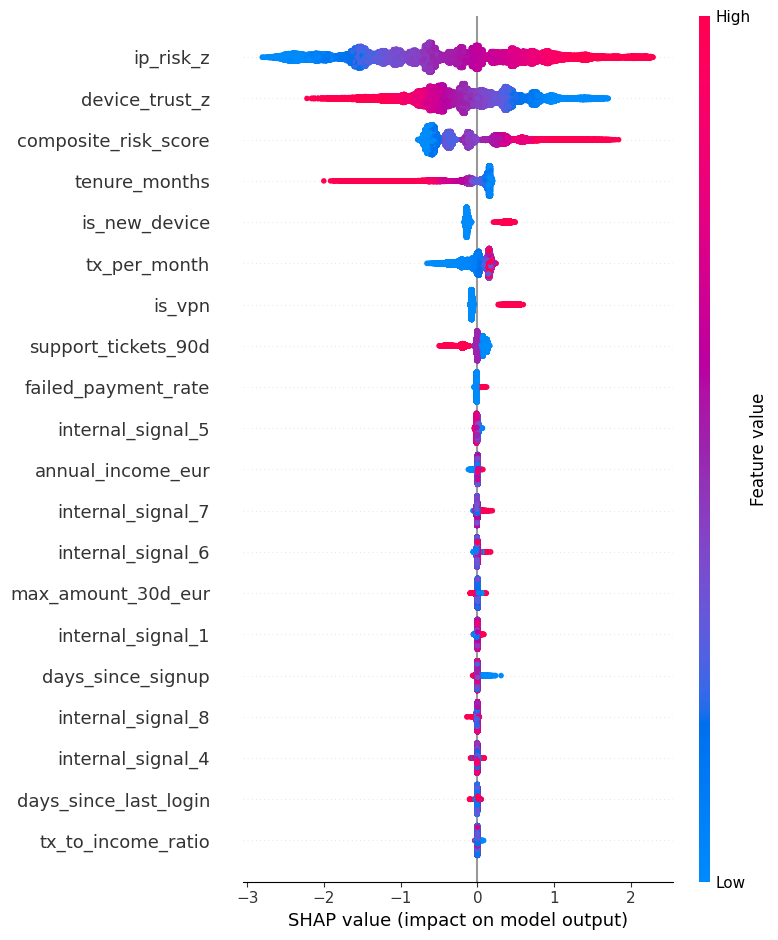

In [196]:
shap.summary_plot(shap_values, X_test)

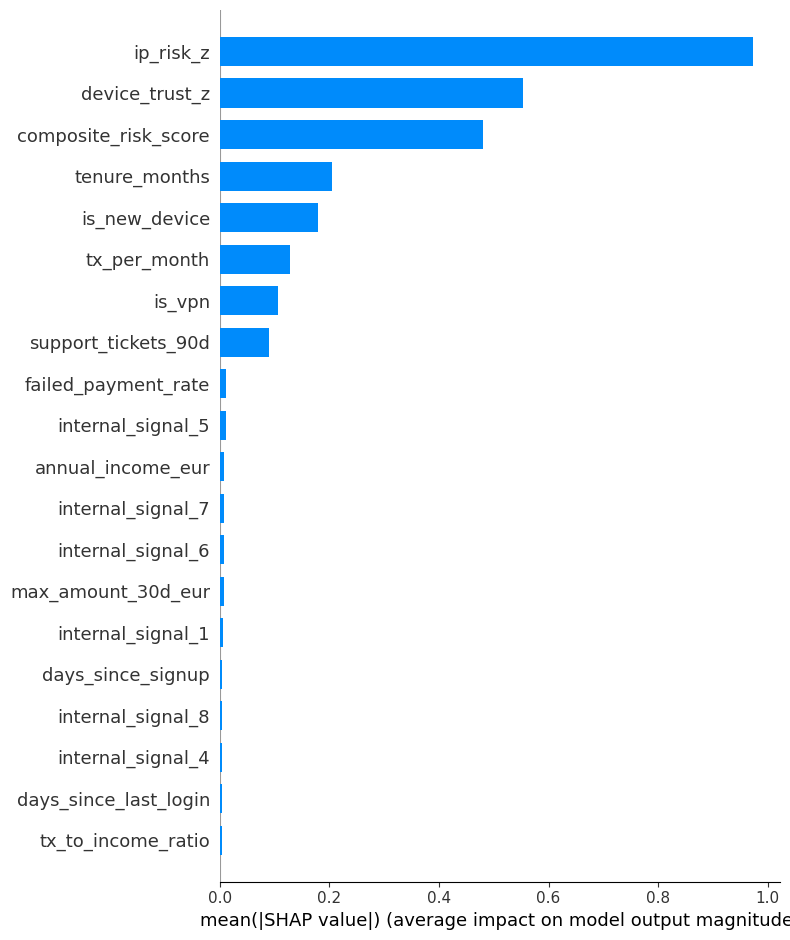

In [197]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

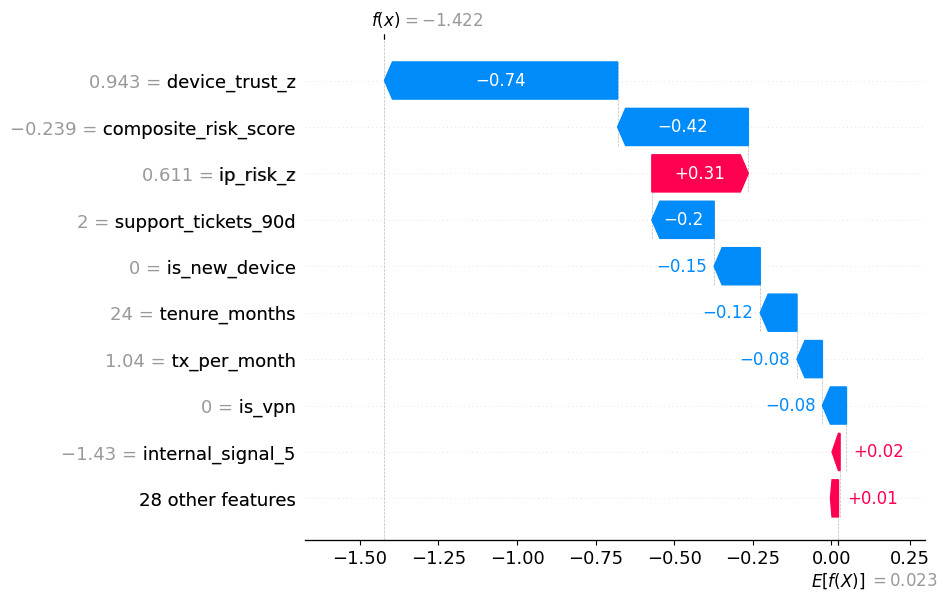

In [198]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)